In [1]:
# Artemis II Data Methodology Challenge
# Within-Subject Longitudinal Baseline Comparison Framework
# Proxy Dataset: NHANES Sleep and Stress Indicators

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

# Create data directory
os.makedirs('data', exist_ok=True)

# Download NHANES files (2017-2018 cycle)
files = {
    'sleep': 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/SLQ_J.XPT',
    'depression': 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DPQ_J.XPT',
    'demographics': 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DEMO_J.XPT'
}

for name, url in files.items():
    filepath = f'data/{name}.xpt'
    if not os.path.exists(filepath):
        print(f'Downloading {name}...')
        urllib.request.urlretrieve(url, filepath)
        print(f'{name} downloaded.')

print('All files ready.')


All files ready.


In [2]:
# Load the datasets
sleep = pd.read_sas('data/sleep.xpt', format='xport', encoding='utf-8')
depression = pd.read_sas('data/depression.xpt', format='xport', encoding='utf-8')
demographics = pd.read_sas('data/demographics.xpt', format='xport', encoding='utf-8')

# Preview sleep data
print("Sleep dataset shape:", sleep.shape)
print("Depression dataset shape:", depression.shape)
print("Demographics dataset shape:", demographics.shape)
print("\nSleep columns:", list(sleep.columns))


Sleep dataset shape: (6161, 11)
Depression dataset shape: (5533, 11)
Demographics dataset shape: (9254, 46)

Sleep columns: ['SEQN', 'SLQ300', 'SLQ310', 'SLD012', 'SLQ320', 'SLQ330', 'SLD013', 'SLQ030', 'SLQ040', 'SLQ050', 'SLQ120']


In [3]:
# Merge all three datasets on SEQN (person ID)
df = demographics.merge(sleep, on='SEQN', how='inner')
df = df.merge(depression, on='SEQN', how='inner')

print("Merged dataset shape:", df.shape)

# Filter astronaut-like cohort
# Age 25-55, educated adults
cohort = df[
    (df['RIDAGEYR'] >= 25) & 
    (df['RIDAGEYR'] <= 55) &
    (df['DMDEDUC2'] >= 4)   # Some college or higher
]

print("Astronaut-like cohort size:", len(cohort))

Merged dataset shape: (5533, 66)
Astronaut-like cohort size: 1529


In [4]:
# Select key variables for analysis
cohort = cohort[['SEQN', 'RIDAGEYR', 'DMDEDUC2', 'SLD012', 'SLD013', 'SLQ120', 
                  'DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050',
                  'DPQ060', 'DPQ070', 'DPQ080', 'DPQ090']].copy()

# Calculate PHQ-9 total score (stress/depression indicator)
phq_cols = ['DPQ010','DPQ020','DPQ030','DPQ040','DPQ050',
            'DPQ060','DPQ070','DPQ080','DPQ090']

cohort['PHQ9_total'] = cohort[phq_cols].sum(axis=1)

# Calculate average sleep duration across weekday and weekend
cohort['avg_sleep'] = (cohort['SLD012'] + cohort['SLD013']) / 2

# Drop rows with missing values
cohort = cohort.dropna(subset=['avg_sleep', 'PHQ9_total', 'SLQ120'])

print("Final cohort size after cleaning:", len(cohort))
print("\nSleep duration stats:")
print(cohort['avg_sleep'].describe())
print("\nPHQ-9 stress score stats:")
print(cohort['PHQ9_total'].describe())

Final cohort size after cleaning: 1518

Sleep duration stats:
count    1518.000000
mean        7.808300
std         1.249447
min         3.000000
25%         7.000000
50%         8.000000
75%         8.500000
max        12.000000
Name: avg_sleep, dtype: float64

PHQ-9 stress score stats:
count    1.518000e+03
mean     2.838603e+00
std      3.871831e+00
min      0.000000e+00
25%      4.857845e-78
50%      1.000000e+00
75%      4.000000e+00
max      2.200000e+01
Name: PHQ9_total, dtype: float64


In [5]:
np.random.seed(42)
subjects = cohort.sample(n=4).copy()
subjects['subject_id'] = ['Subject_1', 'Subject_2', 'Subject_3', 'Subject_4']

sleep_baseline_mean = cohort['avg_sleep'].mean()
sleep_baseline_std = cohort['avg_sleep'].std()
phq_baseline_mean = cohort['PHQ9_total'].mean()
phq_baseline_std = cohort['PHQ9_total'].std()

subjects['sleep_deviation'] = (subjects['avg_sleep'] - sleep_baseline_mean) / sleep_baseline_std
subjects['stress_deviation'] = (subjects['PHQ9_total'] - phq_baseline_mean) / phq_baseline_std

print("Our 4 simulated astronaut-like subjects:")
print(subjects[['subject_id', 'avg_sleep', 'PHQ9_total', 'sleep_deviation', 'stress_deviation']])

Our 4 simulated astronaut-like subjects:
     subject_id  avg_sleep  PHQ9_total  sleep_deviation  stress_deviation
953   Subject_1        8.5        14.0         0.553605          2.882718
4451  Subject_2        9.0         0.0         0.953782         -0.733142
4529  Subject_3        7.5         2.0        -0.246749         -0.216591
5358  Subject_4        5.5         1.0        -1.847458         -0.474867


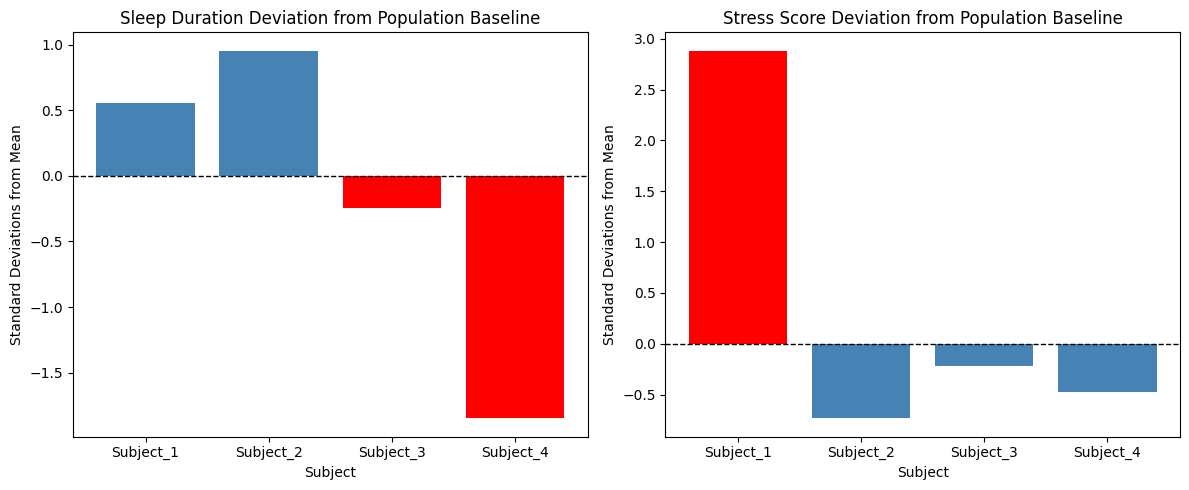

Plot saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sleep deviation plot
axes[0].bar(subjects['subject_id'], subjects['sleep_deviation'], 
            color=['red' if x < 0 else 'steelblue' for x in subjects['sleep_deviation']])
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Sleep Duration Deviation from Population Baseline')
axes[0].set_ylabel('Standard Deviations from Mean')
axes[0].set_xlabel('Subject')

# Stress deviation plot
axes[1].bar(subjects['subject_id'], subjects['stress_deviation'],
            color=['red' if x > 0 else 'steelblue' for x in subjects['stress_deviation']])
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Stress Score Deviation from Population Baseline')
axes[1].set_ylabel('Standard Deviations from Mean')
axes[1].set_xlabel('Subject')

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150)
plt.show()
print("Plot saved.")

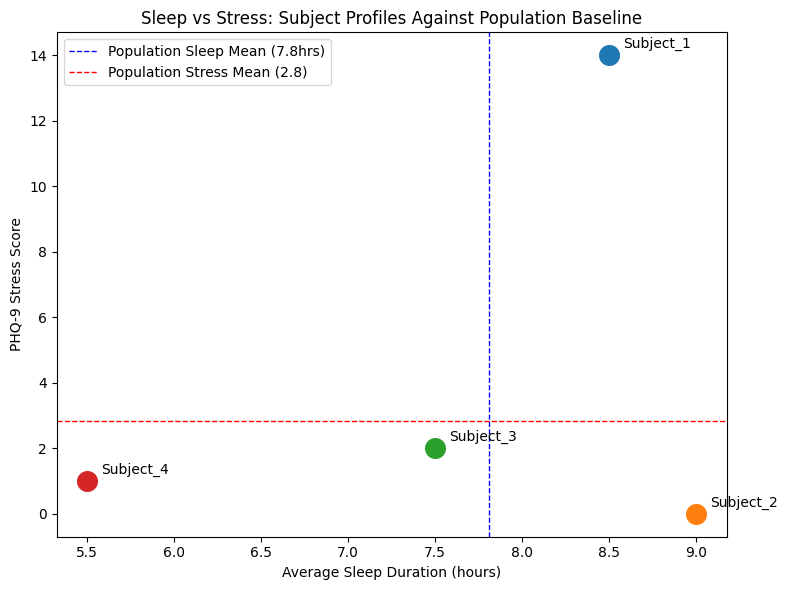

Plot saved.


In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in subjects.iterrows():
    ax.scatter(row['avg_sleep'], row['PHQ9_total'], s=200, zorder=5)
    ax.annotate(row['subject_id'], 
                (row['avg_sleep'], row['PHQ9_total']),
                textcoords="offset points",
                xytext=(10, 5),
                fontsize=10)

# Add population mean reference lines
ax.axvline(x=sleep_baseline_mean, color='blue', linestyle='--', 
           linewidth=1, label=f'Population Sleep Mean ({sleep_baseline_mean:.1f}hrs)')
ax.axhline(y=phq_baseline_mean, color='red', linestyle='--', 
           linewidth=1, label=f'Population Stress Mean ({phq_baseline_mean:.1f})')

ax.set_xlabel('Average Sleep Duration (hours)')
ax.set_ylabel('PHQ-9 Stress Score')
ax.set_title('Sleep vs Stress: Subject Profiles Against Population Baseline')
ax.legend()

plt.tight_layout()
plt.savefig('sleep_vs_stress.png', dpi=150)
plt.show()
print("Plot saved.")

In [8]:
print("=" * 60)
print("WITHIN-SUBJECT BASELINE COMPARISON - SUMMARY REPORT")
print("=" * 60)
print(f"\nPopulation Baseline (n={len(cohort)} astronaut-like subjects)")
print(f"  Average Sleep Duration: {sleep_baseline_mean:.2f} hours (SD={sleep_baseline_std:.2f})")
print(f"  Average PHQ-9 Score:    {phq_baseline_mean:.2f} (SD={phq_baseline_std:.2f})")

print("\nIndividual Subject Profiles:")
print("-" * 60)
for _, row in subjects.iterrows():
    print(f"\n{row['subject_id']}:")
    print(f"  Sleep Duration:  {row['avg_sleep']:.1f} hrs  (deviation: {row['sleep_deviation']:+.2f} SD)")
    print(f"  PHQ-9 Score:     {row['PHQ9_total']:.1f}      (deviation: {row['stress_deviation']:+.2f} SD)")
    
    if row['sleep_deviation'] < -1:
        print("  ⚠️  Notable sleep deficit relative to population baseline")
    if row['stress_deviation'] > 1:
        print("  ⚠️  Elevated stress relative to population baseline")

print("\n" + "=" * 60)
print("Methodology: Within-Subject Baseline Comparison Framework")
print("Proxy Dataset: NHANES 2017-2018")
print("Cohort Filter: Adults 25-55, college educated")
print("=" * 60)

WITHIN-SUBJECT BASELINE COMPARISON - SUMMARY REPORT

Population Baseline (n=1518 astronaut-like subjects)
  Average Sleep Duration: 7.81 hours (SD=1.25)
  Average PHQ-9 Score:    2.84 (SD=3.87)

Individual Subject Profiles:
------------------------------------------------------------

Subject_1:
  Sleep Duration:  8.5 hrs  (deviation: +0.55 SD)
  PHQ-9 Score:     14.0      (deviation: +2.88 SD)
  ⚠️  Elevated stress relative to population baseline

Subject_2:
  Sleep Duration:  9.0 hrs  (deviation: +0.95 SD)
  PHQ-9 Score:     0.0      (deviation: -0.73 SD)

Subject_3:
  Sleep Duration:  7.5 hrs  (deviation: -0.25 SD)
  PHQ-9 Score:     2.0      (deviation: -0.22 SD)

Subject_4:
  Sleep Duration:  5.5 hrs  (deviation: -1.85 SD)
  PHQ-9 Score:     1.0      (deviation: -0.47 SD)
  ⚠️  Notable sleep deficit relative to population baseline

Methodology: Within-Subject Baseline Comparison Framework
Proxy Dataset: NHANES 2017-2018
Cohort Filter: Adults 25-55, college educated
